In [25]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('/content/drive/MyDrive/data/togo-dapaong_qc.csv',parse_dates=["Timestamp"])

In [44]:
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


In [45]:
missing_report = df.isna().sum().to_frame("missing_count")
missing_report["missing_percent"] = 100 * missing_report["missing_count"] / len(df)
missing_report

,missing_count,missing_percent
Timestamp,0,0.0
GHI,0,0.0
DNI,0,0.0
DHI,0,0.0
ModA,0,0.0
ModB,0,0.0
Tamb,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


In [46]:
#columns with >5% nulls
cols_5 = missing_report[missing_report["missing_percent"] > 5].index.tolist()
print("Columns with >5% nulls:", cols_5)

Columns with >5% nulls: ['Comments']


In [47]:
key_cols = ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"]
key_cols = [c for c in key_cols if c in df.columns]

In [48]:
#Compute Z-scores
for c in key_cols:
    df[c+"_z"] = stats.zscore(df[c].astype(float), nan_policy='omit')

In [49]:
# Flag outliers (|Z|>3)
df["is_outlier"] = (df[[c+"_z" for c in key_cols]].abs() > 3).any(axis=1)
print("Outliers detected:", df["is_outlier"].sum())

Outliers detected: 9251


In [50]:
# Median imputation for key columns
for c in key_cols:
    df[c] = df[c].fillna(df[c].median())

In [53]:
# Export cleaned CSV (never commit this file)
df.to_csv("data/togo_clean.csv", index=False)

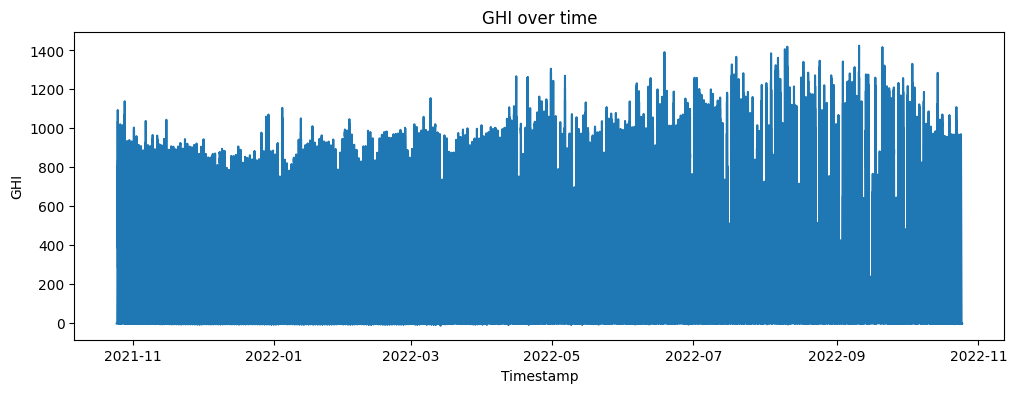

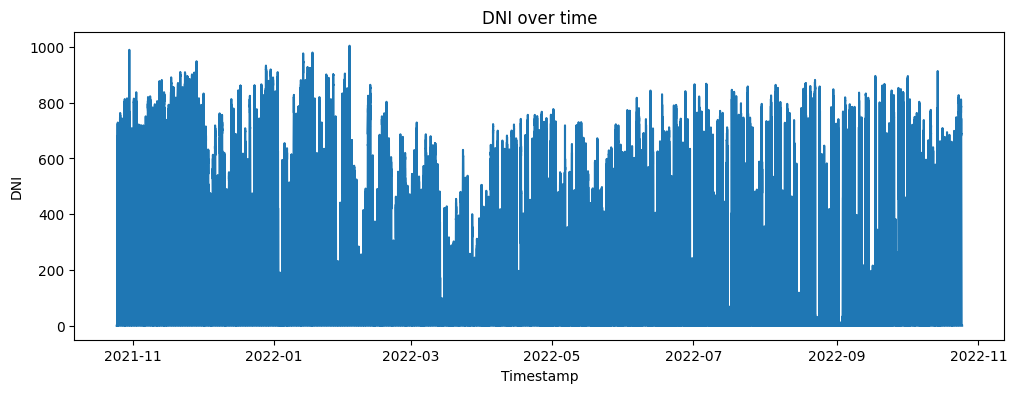

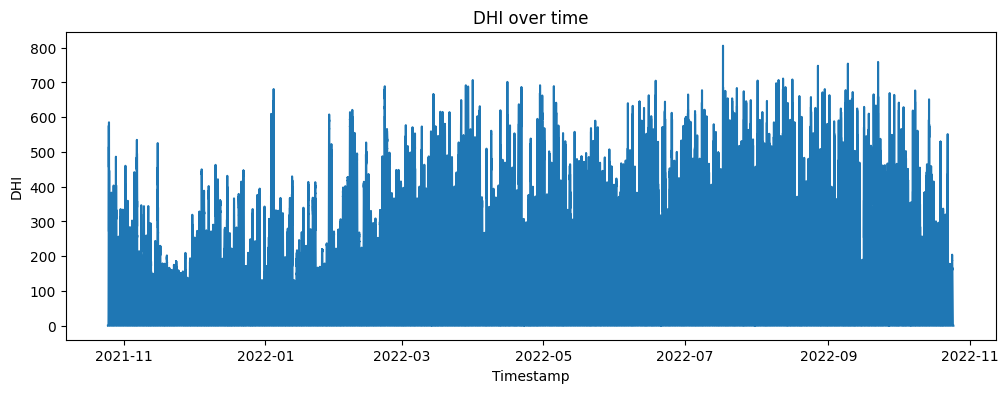

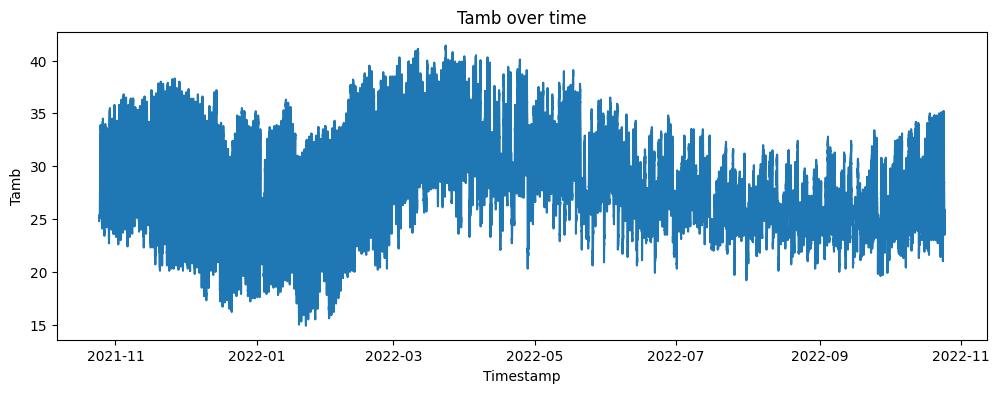

In [54]:
#Time Series Analysis
import matplotlib.pyplot as plt

plot_vars = ["GHI","DNI","DHI","Tamb"]
for col in plot_vars:
    if col in df.columns:
        plt.figure(figsize=(12,4))
        plt.plot(df["Timestamp"], df[col])
        plt.title(f"{col} over time")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.show()


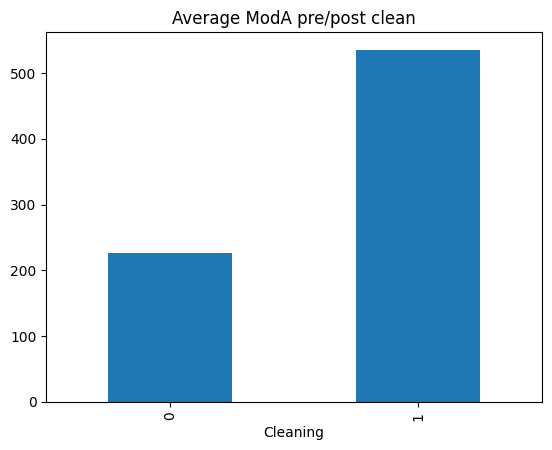

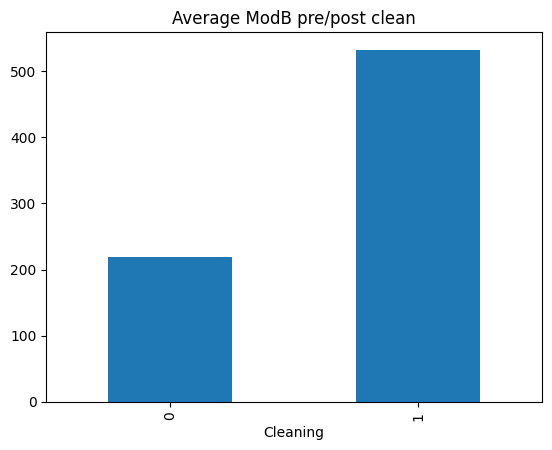

In [55]:
#Cleaning Impact (pre vs post clean)
for col in ["ModA","ModB"]:
    if col in df.columns:
        avg = df.groupby("Cleaning")[col].mean()
        avg.plot(kind="bar", title=f"Average {col} pre/post clean")
        plt.show()


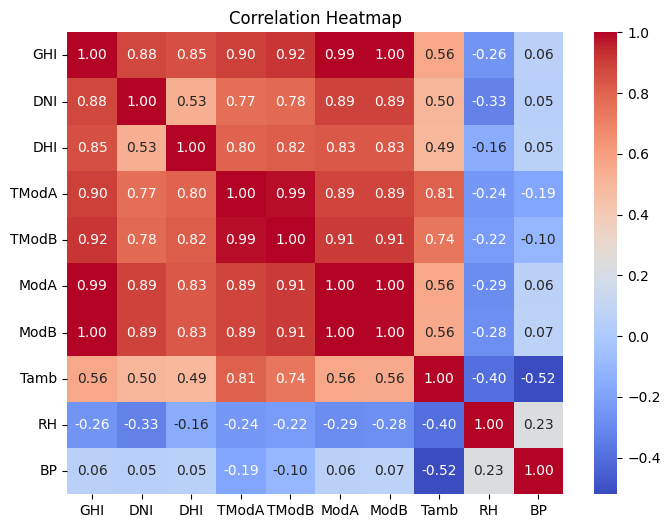

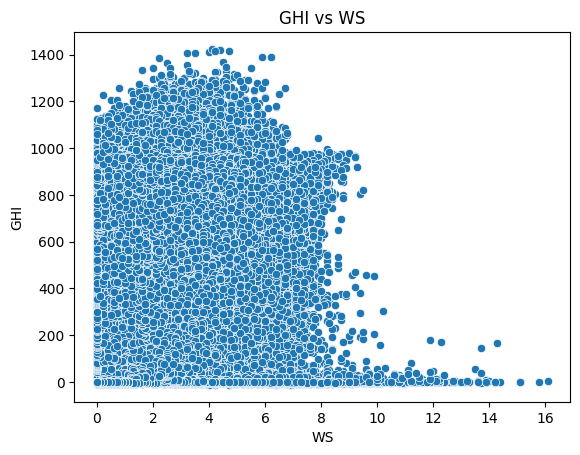

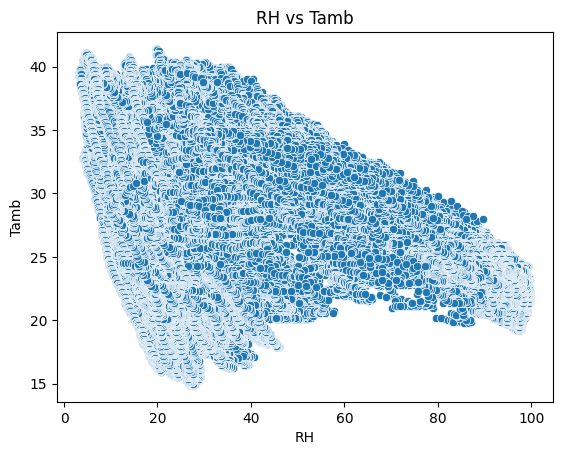

In [56]:
#Correlation & Relationship Analysis


corr_cols = ["GHI","DNI","DHI","TModA","TModB","ModA","ModB","Tamb","RH","BP"]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


sns.scatterplot(data=df, x="WS", y="GHI")
plt.title("GHI vs WS")
plt.show()

sns.scatterplot(data=df, x="RH", y="Tamb")
plt.title("RH vs Tamb")
plt.show()


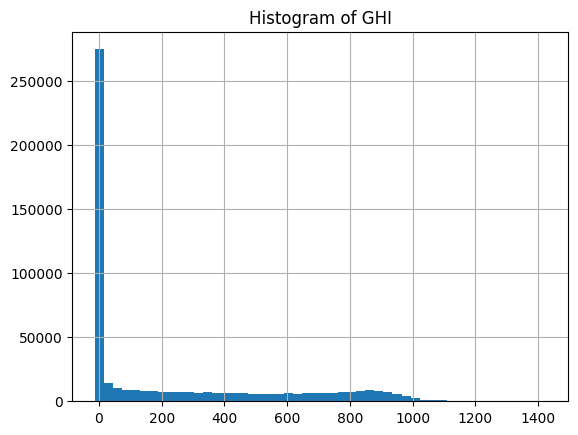

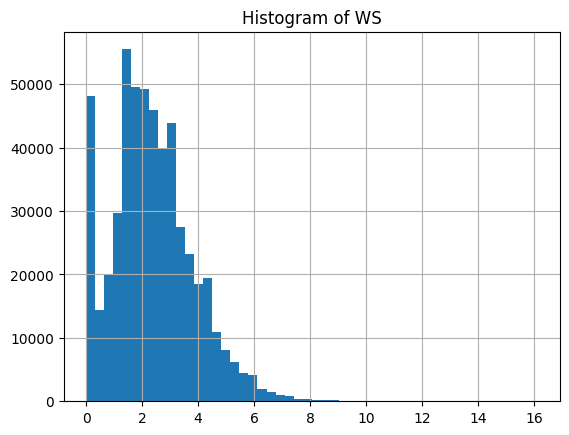

In [57]:
#Wind & Distribution Analysis
df["GHI"].hist(bins=50)
plt.title("Histogram of GHI")
plt.show()

df["WS"].hist(bins=50)
plt.title("Histogram of WS")
plt.show()


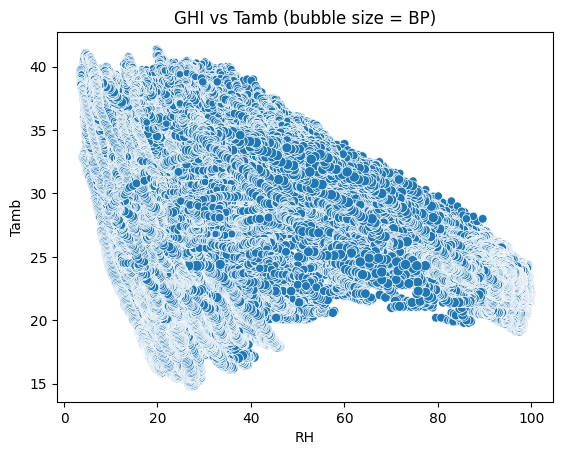

In [58]:
#Temperature Analysis (RH vs Tamb / GHI)
sns.scatterplot(data=df, x="RH", y="Tamb", size="BP", legend=False)
plt.title("GHI vs Tamb (bubble size = BP)")
plt.show()


/tmp/ipython-input-2435093286.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


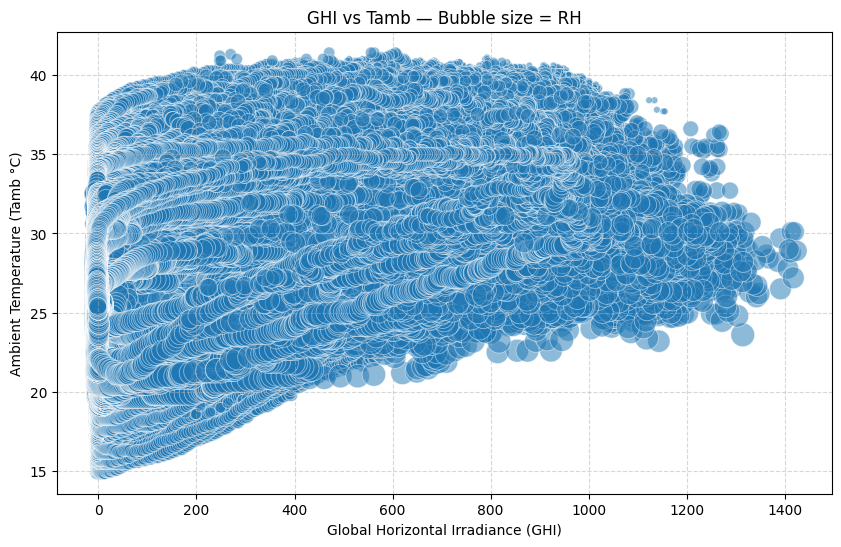

In [59]:
bubble_size_col = "RH"

if all(col in df.columns for col in ["GHI", "Tamb", bubble_size_col]):
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=df,
        x="GHI",
        y="Tamb",
        size=bubble_size_col,
        sizes=(20, 300),
        alpha=0.5,
        palette="viridis",
        legend=False
    )
    plt.title(f"GHI vs Tamb — Bubble size = {bubble_size_col}")
    plt.xlabel("Global Horizontal Irradiance (GHI)")
    plt.ylabel("Ambient Temperature (Tamb °C)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
else:
    print("⚠️ Missing one of: GHI, Tamb, or chosen bubble variable (RH/BP)")
